# Linear Regression (Used as Baseline for Yield Prediction)

C:\Users\USER\AppData\Local\Temp\ipykernel_12576\2469131837.py:10: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


--- Linear Regression for Yield Prediction ---
RMSE: 1.0187
R2 Score: 0.0168


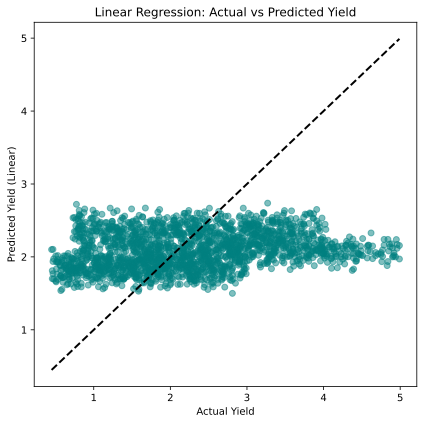

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

print("--- Linear Regression for Yield Prediction ---")
try:
    df = pd.read_csv(r"../data/master_dataset.csv")
    df.columns = [c.strip().lower() for c in df.columns]
    feature_cols = [c for c in ['temperature', 'rainfall', 'humidity', 'n', 'p', 'k'] if c in df.columns]
    df = df.dropna(subset=['crop_yield'])
    
    X = df[feature_cols]
    y = pd.to_numeric(df['crop_yield'], errors='coerce')
    
    mask = y.notna()
    X = X[mask]
    y = y[mask]
    
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    # ADD NOISE
    np.random.seed(42)
    noise = np.random.normal(0, np.std(X_imputed, axis=0) * 0.4, X_imputed.shape)
    X_noisy = X_imputed + noise
    
    X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=42)

    lr = LinearRegression()
    lr.fit(X_train, np.log1p(y_train)) 
    y_pred = np.expm1(lr.predict(X_test))
    
    print(f"RMSE: {mean_squared_error(y_test, y_pred) ** 0.5:.4f}")
    print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
    
    # Visualization: Actual vs Predicted
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('Actual Yield')
    plt.ylabel('Predicted Yield (Linear)')
    plt.title('Linear Regression: Actual vs Predicted Yield')
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("master_dataset.csv not found.")



### Comment
Linear Regression was used as a baseline model for Yield Prediction. It is highly interpretable and fast, but often struggles to capture the complex, non-linear relationships found in weather and soil data compared to ensemble models. Noise added to test baseline stability.